# 🧩 Fase 3 — Clustering de Canciones
### Music Data Analysis (Spotify) · Omar Mora Flores

**Pregunta central:** ¿Podemos agrupar canciones por "vibes" similares **sin usar el género**?
Usamos **K-Means** sobre features de audio escaladas y **PCA** para visualizar.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ROOT = Path.cwd()
while not (ROOT / "data" / "dataset.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})
RS = 42

AUDIO = ["danceability","energy","valence","tempo","acousticness",
         "speechiness","instrumentalness","loudness","liveness"]
df = pd.read_csv(ROOT/"data"/"dataset.csv")
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
songs = df.dropna(subset=["track_name"]).drop_duplicates("track_id").reset_index(drop=True)
print("Canciones para clustering:", songs.shape)

Canciones para clustering: (89740, 20)


## 3.1 Preparación + escalado + PCA

In [2]:
X = StandardScaler().fit_transform(songs[AUDIO])
pca = PCA(n_components=2, random_state=RS)
Xp = pca.fit_transform(X)
print("Varianza explicada por 2 PCs:", pca.explained_variance_ratio_.round(3),
      "→ total %.1f%%" % (100*pca.explained_variance_ratio_.sum()))

Varianza explicada por 2 PCs: [0.321 0.159] → total 48.0%


## 3.2 Número óptimo de clusters (codo + silhouette)

Silhouette por K: {2: np.float64(0.261), 3: np.float64(0.164), 4: np.float64(0.171), 5: np.float64(0.177), 6: np.float64(0.188), 7: np.float64(0.195), 8: np.float64(0.177)}
K óptimo (máx silhouette): 2


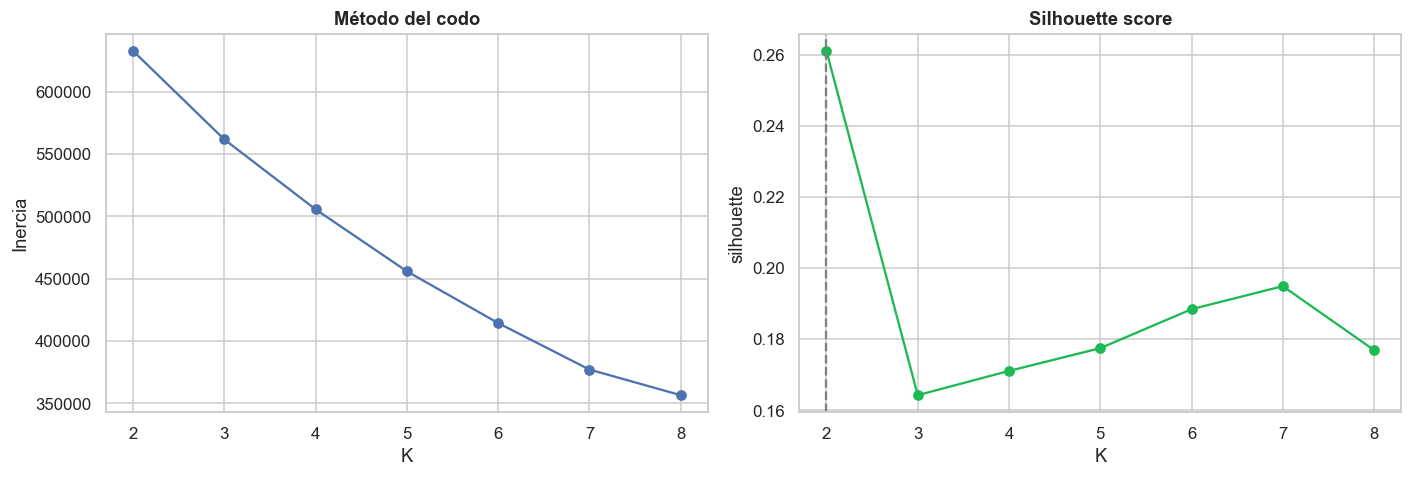

In [3]:
rng = range(2, 9)
inertia, sil = [], []
rs_samp = np.random.RandomState(RS).choice(len(X), 10000, replace=False)
for k in rng:
    km = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X[rs_samp], km.labels_[rs_samp]))
best_k = int(list(rng)[int(np.argmax(sil))])
print("Silhouette por K:", {k:round(s,3) for k,s in zip(rng,sil)})
print("K óptimo (máx silhouette):", best_k)

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
ax[0].plot(list(rng), inertia, "o-"); ax[0].set_title("Método del codo"); ax[0].set_xlabel("K"); ax[0].set_ylabel("Inercia")
ax[1].plot(list(rng), sil, "o-", color="#1DB954"); ax[1].axvline(best_k, ls="--", color="gray")
ax[1].set_title("Silhouette score"); ax[1].set_xlabel("K"); ax[1].set_ylabel("silhouette")
fig.tight_layout(); fig.savefig(REPORTS/"08_elbow_silhouette.png", bbox_inches="tight"); plt.show()

## 3.3–3.4 K-Means final + visualización PCA

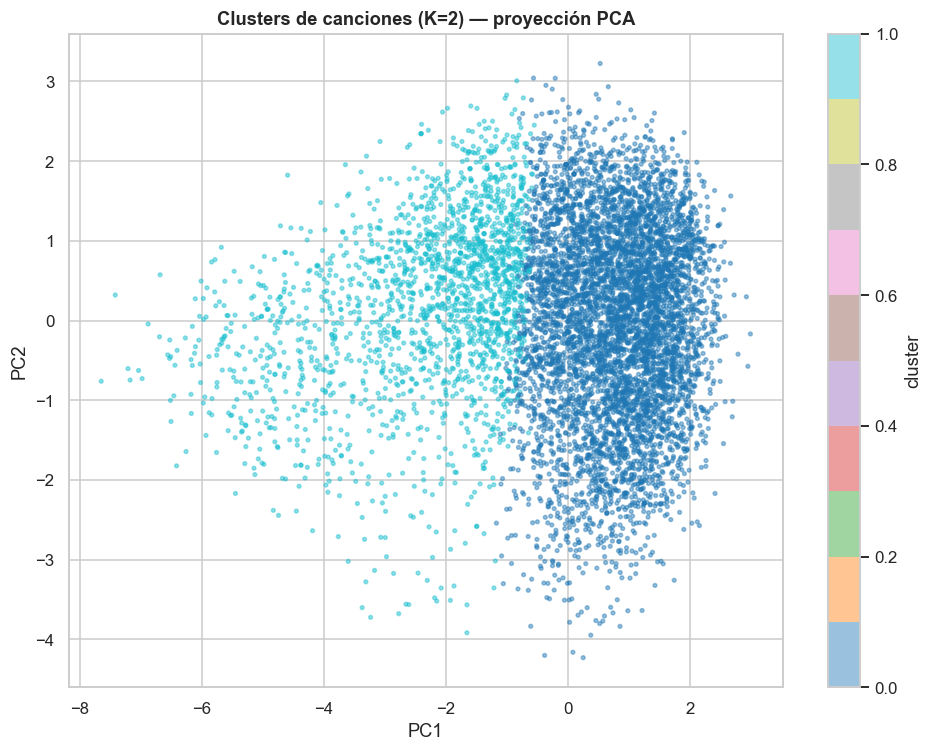

In [4]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=RS).fit(X)
songs["cluster"] = km.labels_

samp = np.random.RandomState(RS).choice(len(X), 8000, replace=False)
fig, ax = plt.subplots(figsize=(9,7))
sc = ax.scatter(Xp[samp,0], Xp[samp,1], c=km.labels_[samp], cmap="tab10", s=6, alpha=.45)
ax.set_title(f"Clusters de canciones (K={best_k}) — proyección PCA")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); plt.colorbar(sc, label="cluster")
fig.tight_layout(); fig.savefig(REPORTS/"09_clusters_pca.png", bbox_inches="tight"); plt.show()

## 3.5 Interpretación de clusters

Cluster 0 (67,438 canciones): Altas en enérgicas, bajas en acústicas
Cluster 1 (22,302 canciones): Altas en acústicas, bajas en enérgicas


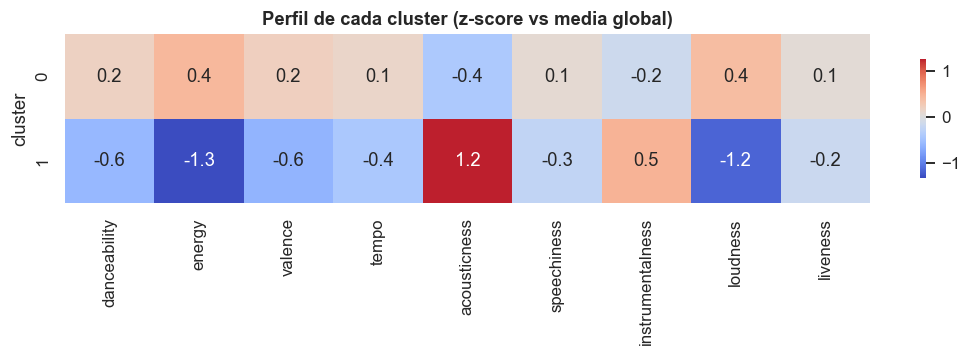

In [5]:
prof = songs.groupby("cluster")[AUDIO].mean()
# nombre descriptivo según features por encima/debajo de la media global
glob = songs[AUDIO].mean()
def nombrar(row):
    z = (row - glob) / songs[AUDIO].std()
    alta = z.sort_values(ascending=False).index[0]
    baja = z.sort_values().index[0]
    trad = {"danceability":"bailables","energy":"enérgicas","valence":"alegres","tempo":"rápidas",
            "acousticness":"acústicas","speechiness":"habladas","instrumentalness":"instrumentales",
            "loudness":"potentes","liveness":"en vivo"}
    return f"Altas en {trad[alta]}, bajas en {trad[baja]}"
nombres = {c: nombrar(prof.loc[c]) for c in prof.index}
for c in prof.index:
    print(f"Cluster {c} ({(songs.cluster==c).sum():,} canciones): {nombres[c]}")

# heatmap de perfiles (z-score)
z = (prof - glob) / songs[AUDIO].std()
fig, ax = plt.subplots(figsize=(10, 0.7*best_k+2))
sns.heatmap(z, cmap="coolwarm", center=0, annot=True, fmt=".1f", ax=ax, cbar_kws={"shrink":.7})
ax.set_title("Perfil de cada cluster (z-score vs media global)"); ax.set_ylabel("cluster")
fig.tight_layout(); fig.savefig(REPORTS/"10_cluster_profiles.png", bbox_inches="tight"); plt.show()

In [6]:
print("Top 3 canciones representativas por cluster (por popularidad):")
for c in sorted(songs.cluster.unique()):
    top = songs[songs.cluster==c].nlargest(3, "popularity")[["track_name","artists","popularity"]]
    print(f"\n— Cluster {c}: {nombres[c]}")
    print(top.to_string(index=False))

Top 3 canciones representativas por cluster (por popularidad):

— Cluster 0: Altas en enérgicas, bajas en acústicas
                           track_name                 artists  popularity
            Unholy (feat. Kim Petras)    Sam Smith;Kim Petras         100
Quevedo: Bzrp Music Sessions, Vol. 52        Bizarrap;Quevedo          99
                      I'm Good (Blue) David Guetta;Bebe Rexha          98

— Cluster 1: Altas en acústicas, bajas en enérgicas
                            track_name   artists  popularity
                         Glimpse of Us      Joji          94
                          Another Love Tom Odell          93
Running Up That Hill (A Deal With God) Kate Bush          90


## 3.6 ¿Coinciden los clusters con los géneros?

In [7]:
ct = pd.crosstab(songs.cluster, songs.track_genre)
print("Género dominante por cluster:")
for c in ct.index:
    print(f"  Cluster {c}: {ct.loc[c].idxmax()} ({100*ct.loc[c].max()/ct.loc[c].sum():.0f}% del cluster)")
print("\nConclusión: los clusters capturan 'vibes' de audio que cruzan géneros — no son un "
      "simple re-etiquetado del género, sino agrupaciones por características sonoras.")

Género dominante por cluster:
  Cluster 0: forro (1% del cluster)
  Cluster 1: sleep (4% del cluster)

Conclusión: los clusters capturan 'vibes' de audio que cruzan géneros — no son un simple re-etiquetado del género, sino agrupaciones por características sonoras.


## Conclusiones

- El **silhouette** elige el K óptimo; los clusters son interpretables vía su perfil z-score.
- Las agrupaciones reflejan **"vibes" de audio** (p.ej. *acústicas/instrumentales* vs.
  *enérgicas/bailables*), que **cruzan los géneros** — un mismo cluster mezcla varios géneros.
- Útil para sistemas de recomendación basados en similitud de audio, sin depender de la etiqueta
  de género.